In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam

from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm

In [3]:
def add_noise(x0,t, alpha_bars):
    # Compute the noise
    noise = torch.randn_like(x0)
    # Get the wanted alpha bar
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    # Compute xt
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    return x_t, noise

In [4]:
def tokenize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s-]', '', text)
    text = text.replace('-', ' - ')
    return text.split()

def tokenize_dataset(texts):
    word_counts = Counter()
    for text in texts:
        word_counts.update(tokenize_text(text))

    special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

    vocab = special_tokens + [word for word, count in word_counts.most_common()]

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return vocab, word2idx, idx2word
    
def encode(text, max_len,word2idx):
    tokens = tokenize_text(text)
    ids = [word2idx['<BOS>']]
    ids += [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    ids += [word2idx['<EOS>']]
    # Pad or truncate
    ids = ids[:max_len]
    ids += [word2idx['<PAD>']] * (max_len - len(ids))
    return ids

def decode(ids,word2idx,idx2word):
    words = [idx2word[i] for i in ids 
             if i not in [word2idx['<PAD>'], word2idx['<BOS>'], word2idx['<EOS>']]]
    return ' '.join(words)

def plot_token_info(texts):
    token_lengths = [len(tokenize_text(text)) for text in texts]
    avg_len = sum(token_lengths) / len(token_lengths)

    # Histogram
    plt.figure(figsize=(10, 4))
    plt.hist(token_lengths, bins=20, color='steelblue', edgecolor='white')
    plt.axvline(avg_len, color='red', linestyle='--', label=f'Average ({avg_len:.1f})')
    plt.axvline(max(token_lengths), color='orange', linestyle='--', label=f'Max ({max(token_lengths)})')
    plt.xlabel("Number of tokens")
    plt.ylabel("Number of samples")
    plt.title("PixelDiffusion — Token length distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=4, ff_mult=4):
        super().__init__()

        # Self Attention
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)

        # MLP/Feed Forward
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * ff_mult),
            nn.GELU(),
            nn.Linear(dim * ff_mult, dim)
        )

    def forward(self, x, padding_mask=None):
        
        # Attention
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=padding_mask)
        # Residual
        x  = x + attn_out

        # Feed Forward + Residual
        x = x + self.ff(self.norm2(x))
        return x
    

class TextEncoder(nn.Module):
    def __init__(self, vocab_size, dim=128, n_layers=4, n_heads=4, max_len=28):
        """
        vocab_size : size of your tokenizer vocabulary
        dim        : embedding dimension
        n_layers   : number of transformer blocks
        n_heads    : number of attention heads
        max_len    : maximum sequence length
        """
        super().__init__()

        self.dim = dim

        # Embedding (Pos + Token)
        # Each token is projected into a space of dimension dim
        self.token_emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        # Reguarding the position of the token he is also projected into a space of dimension dim
        self.pos_emb = nn.Embedding(max_len, dim)

        # Transformersblocks
        self.blocks = nn.ModuleList([
            TransformerBlock(dim, n_heads) for _ in range(n_layers)
        ])

        # Norm
        self.norm = nn.LayerNorm(dim)

    def forward(self, tokens, padding_mask=None):
        """
        tokens       : (B, seq_len) token ids
        padding_mask : (B, seq_len) True where padding
        returns      : (B, seq_len, dim) text embeddings
        """
        B, seq_len = tokens.shape

        # Embedding
        # To get the positions of each tokens
        positions = torch.arange(seq_len, device=tokens.device).unsqueeze(0)  # (1, seq_len)

        # Compute the embedding
        x = self.token_emb(tokens) + self.pos_emb(positions) # (B, seq_len, dim)

        # Transformers block
        for block in self.blocks:
            x = block(x, padding_mask) # to not influence attetion 

        return self.norm(x)   # (B, seq_len, dim)

In [6]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # At this point we could implement on top of the sinusoide embedding a small MLP to project better

    def sinusoidal_embedding(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1)))
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

    def forward(self,t):
        return self.sinusoidal_embedding(t)

class ResBlock(nn.Module):
    def __init__(self, in_channels:int,out_channels:int,emb_dim:int):
        """
        in_channels : number of input channels
        out_channels : number of output channels
        emb_dim : dimension of the timestep embedding
        """

        super().__init__()

        # First block
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels), #split channels into group of 8
            nn.SiLU(),
            nn.Conv2d(in_channels,out_channels, kernel_size=3,padding=1)
        )

        # Embedding projection
        # We need to project the embedding in order to be in the same space while adding
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels)
        )

        # Second block
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels,out_channels, kernel_size=3,padding=1)
        )

        # Skip connection
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) #too match if different
        else:
            self.skip = nn.Identity()

    def forward(self,x,t_emb):
        """
        x     : (B, in_channels, H, W)
        t_emb : (B, emb_dim)
        """

        # First block
        # (B, out_channels, H, W)
        h = self.block1(x)

        # Add time step embedding
        # (B, emb_dim)
        t = self.time_proj(t_emb)
        # (B, out_channels)

        # Add by broadcasting
        h = h + t[:, :, None, None]

        # Second block
        # (B, out_channels, H, W)
        h = self.block2(h)

        # Skip connection
        return h + self.skip(x)
    
class SelfAttention(nn.Module):
    def __init__(self, channels:int,n_heads:int=4):
        """
        channels : number of input/output channels
        n_heads  : number of attention heads
        """
        super().__init__()
        assert channels % n_heads == 0

        self.channels = channels
        self.n_heads = n_heads
        self.head_dim = channels // n_heads

        # Normalization
        self.norm = nn.GroupNorm(8, channels)

        # Q,K,V Linear
        self.qkv = nn.Linear(channels, channels * 3)
        self.output = nn.Linear(channels,channels)

    def forward(self,x):
        """
        x : (B, C, H, W)
        """

        B,C,H,W = x.shape

        # Norm
        h = self.norm(x)

        # Flatten
        h = h.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)

        # Compute Q, K, V
        qkv = self.qkv(h) # (B, H*W, 3*C)
        q,k,v = qkv.chunk(3, dim=-1) # 3*(B, H*W, C)

        # At this point, the differents head are inside q,k,v s we need to split thoses matrix depending on n_heads
        def split_heads(t):
            return t.view(B, H * W, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, H*W, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Dot-product attention
        scale = self.head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale  # (B, n_heads, H*W, H*W)
        attn = torch.softmax(scores, dim=-1) # (B, n_heads, H*W, H*W)

        # Weighted sum of values
        out = torch.matmul(attn, v) # (B, n_heads, H*W, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous() # (B, H*W, n_heads, head_dim)
        out = out.view(B, H * W, C) # (B, H*W, C)

        # Output projection
        out = self.output(out) # (B, H*W, C)

        # Reshape
        out = out.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Return with residual
        return out + x 
    
class CrossAttention(nn.Module):
    def __init__(self, query_dim, context_dim, n_heads=4):
        """
        query_dim   : dimension of image features (from U-Net)
        context_dim : dimension of text embeddings (from Text Encoder)
        n_heads     : number of attention heads
        """
        super().__init__()
        assert query_dim % n_heads == 0, "query_dim must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = query_dim // n_heads
        self.scale = self.head_dim -0.5

        # Normalization
        self.norm_image = nn.LayerNorm(query_dim)
        self.norm_text = nn.LayerNorm(context_dim)

        # Q from image, K and V from text
        self.q_proj = nn.Linear(query_dim, query_dim)
        self.k_proj = nn.Linear(context_dim, query_dim)
        self.v_proj = nn.Linear(context_dim, query_dim)

        # Output
        self.out_proj = nn.Linear(query_dim, query_dim)

    def forward(self, x, context):
        """
        x       : (B, H*W, query_dim)   image features
        context : (B, seq_len, context_dim) text embeddings
        returns : (B, H*W, query_dim)
        """

        # Get the shape
        B, HW, _ = x.shape
        _, seq_len, _ = context.shape

        # Normalize
        x_norm = self.norm_image(x)
        ctx_norm = self.norm_text(context)

        # Compute Q, K, V 
        q = self.q_proj(x_norm) # (B, H*W, query_dim)

        # projection of context_dim to query_dim
        k = self.k_proj(ctx_norm) # (B, seq_len, query_dim)
        v = self.v_proj(ctx_norm) # (B, seq_len, query_dim)

        # Reshape
        q = q.view(B, HW,self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, HW, head_dim)
        k = k.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)
        v = v.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)

        # Scaled dot-product attention
        out = F.scaled_dot_product_attention(q, k, v) # (B, n_heads, HW, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, HW, -1) # (B, HW, query_dim)

        # Output + residual
        return self.out_proj(out) + x # (B, H*W, query_dim)
        

class UNet(nn.Module):
    def __init__(
        self, 
        in_channels:int=3,
        base_channels:int=64,
        channel_mults = (1,2,4),
        n_heads = 4,
        emb_dim =128,
        context_dim=128,
    ):
        super().__init__()

        self.emb_dim = emb_dim
        channels = [base_channels * i for i in channel_mults]

        # Timestep embedding
        self.time_emb = TimestepEmbedding(emb_dim)

        # init conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        ###########
        # Encoder #
        ###########

        # To increase the number of channels and learn multiple features
        self.encoder_blocks = nn.ModuleList()
        # To reduce the size of the input and see the features more precisely/largelly
        self.downsamplers = nn.ModuleList()

        in_ch = base_channels
        for out_ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch, out_ch, emb_dim), # Changes the channel dimension
                ResBlock(out_ch, out_ch, emb_dim), # Work in the same space -> extracts more complex patterns
            ]))
            self.downsamplers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)
            )
            in_ch = out_ch

        ##############
        # Bottleneck #
        ##############
        mid_ch = channels[-1]

        bottleneck_blocks = [
            ResBlock(mid_ch, mid_ch, emb_dim),
            SelfAttention(mid_ch, n_heads),
        ]

        if context_dim is not None:
            bottleneck_blocks.append(CrossAttention(mid_ch, context_dim))

        bottleneck_blocks.append(ResBlock(mid_ch, mid_ch, emb_dim))

        self.bottleneck = nn.ModuleList(bottleneck_blocks)

        ###########
        # Decoder #
        ###########
        # Reduce the number of channels and features
        self.decoder_blocks = nn.ModuleList()
        # Increase the size of the value inside the bottlenck
        self.upsamplers = nn.ModuleList()

        for out_ch in reversed(channels):
            self.upsamplers.append(
                nn.ConvTranspose2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
            )
            self.decoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch + out_ch, out_ch, emb_dim),   # +out_ch for skip connection
                ResBlock(out_ch, out_ch, emb_dim),
            ]))
            in_ch = out_ch

        # Final conv that predict the noise
        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
        )
        
    def forward(self, x, t, text_emb=None):
        """
        x : (B, 3, 64, 64) noisy image
        t : (B,)            timestep
        text_emb : (B, seq_len, context_dim)
        returns predicted noise ε (B, 3, 64, 64)
        """

        # Timestep embedding
        t_emb = self.time_emb(t) # (B, emb_dim)

        x = self.init_conv(x) 

        ### Encoder ###
        skips = []
        for (res1, res2), down in zip(self.encoder_blocks, self.downsamplers):
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock
            skips.append(x)
            x = down(x) # DownSample

        ### Bottleneck ###
        B, C, H, W = x.shape
        
        if text_emb is not None:
            res1, attn, cross, res2 = self.bottleneck
        else:
            res1, attn, res2 = self.bottleneck

        # Classic
        x = res1(x, t_emb)
        x = attn(x)

        # If text conditionning
        if text_emb is not None:
            x_flat = x.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)
            x_flat = cross(x_flat, text_emb) # (B, H*W, C)
            x = x_flat.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Classic
        x = res2(x, t_emb)

        ### Decoder ###
        for (res1, res2), up, skip in zip(self.decoder_blocks, self.upsamplers, reversed(skips)):
            x = up(x) # UpSample
            x = torch.cat([x, skip], dim=1) # Add the residual
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock

        # Final conv
        return self.final(x)

In [11]:
class Loader:
    def __init__(self, checkpoint_path: str, device=None, n_heads: int = 4):
        """
        checkpoint_path : path to the .pt checkpoint file
        device : torch.device (auto-detected if None)
        n_heads : number of attention heads (not stored in checkpoint, must match training)
        """
        self.checkpoint_path = checkpoint_path
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.n_heads = n_heads

    def load(self) -> tuple:
        """
        Loads a checkpoint and returns (unet, text_encoder, meta).

        unet         : UNet ready for inference (eval mode)
        text_encoder : TextEncoder ready for inference, or None if unconditional checkpoint
        meta         : dict with epoch, loss, losses, conditioned
        """
        ckpt = torch.load(self.checkpoint_path, map_location=self.device)
        unet_state = ckpt["unet_state"]

        # Detect conditioned vs unconditioned from checkpoint keys
        # CrossAttention sits at bottleneck[2] and owns q_proj/k_proj/v_proj
        is_conditioned = any("bottleneck.2.q_proj" in k for k in unet_state.keys())

        # Infer UNet hyper-params directly from weight shapes
        in_channels = unet_state["init_conv.weight"].shape[1]
        base_channels = unet_state["init_conv.weight"].shape[0]
        emb_dim = unet_state["encoder_blocks.0.0.time_proj.1.weight"].shape[1]
        channel_mults = self._infer_channel_mults(unet_state, base_channels)
        context_dim = (
            unet_state["bottleneck.2.k_proj.weight"].shape[1]
            if is_conditioned else None
        )

        # Build and load UNet
        unet = UNet(
            in_channels=in_channels,
            base_channels=base_channels,
            channel_mults=channel_mults,
            n_heads=self.n_heads,
            emb_dim=emb_dim,
            context_dim=context_dim,
        ).to(self.device)

        unet.load_state_dict(unet_state, strict=True)
        unet.eval()

        # Build and load TextEncoder (conditioned checkpoints only)
        text_encoder = None
        if is_conditioned and "text_encoder_state" in ckpt:
            enc_state = ckpt["text_encoder_state"]
            vocab_size = enc_state["token_emb.weight"].shape[0]
            dim = enc_state["token_emb.weight"].shape[1]
            max_len = enc_state["pos_emb.weight"].shape[0]
            n_layers = sum(
                1 for k in enc_state
                if k.startswith("blocks.") and k.endswith(".norm1.weight")
            )

            text_encoder = TextEncoder(
                vocab_size=vocab_size,
                dim=dim,
                n_layers=n_layers,
                n_heads=self.n_heads,
                max_len=max_len,
            ).to(self.device)
            text_encoder.load_state_dict(enc_state, strict=True)
            text_encoder.eval()

        meta = {
            "epoch" : ckpt.get("epoch", 0),
            "loss" : ckpt.get("loss", None),
            "losses" : ckpt.get("losses", []),
            "conditioned": is_conditioned,
        }

        print(f"Loaded {'conditioned' if is_conditioned else 'unconditional'} checkpoint "
              f"(epoch {meta['epoch']}) from {self.checkpoint_path}")

        return unet, text_encoder, meta

    def _infer_channel_mults(self, unet_state: dict, base_channels: int) -> tuple:
        """Reconstruct channel_mults by reading encoder block output shapes."""
        mults, i = [], 0
        while f"encoder_blocks.{i}.0.block1.2.weight" in unet_state:
            out_ch = unet_state[f"encoder_blocks.{i}.0.block1.2.weight"].shape[0]
            mults.append(out_ch // base_channels)
            i += 1
        return tuple(mults)

In [17]:
# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
T = 1000
checkpoint_path = "/kaggle/input/datasets/punchi0/pd160pt/pixeldiffusion_conditionned_epoch_160.pt"
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = (1 - betas).to(device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

In [8]:
# Load the dataset
dataset = load_dataset("jiovine/pixel-art-nouns")['train']

README.md:   0%|          | 0.00/405 [00:00<?, ?B/s]

data/train-00000-of-00001-b0bd40c02bb2b3(…):   0%|          | 0.00/328M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49859 [00:00<?, ? examples/s]

In [9]:
# Get word2ix and vocab_size 
vocab, word2idx, _ = tokenize_dataset(dataset['text'])
max_len = 30

In [18]:
# Load the trained model
loader = Loader(checkpoint_path)
unet, text_encoder, meta = loader.load()

Loaded conditioned checkpoint (epoch 160) from /kaggle/input/datasets/punchi0/pd160pt/pixeldiffusion_conditionned_epoch_160.pt


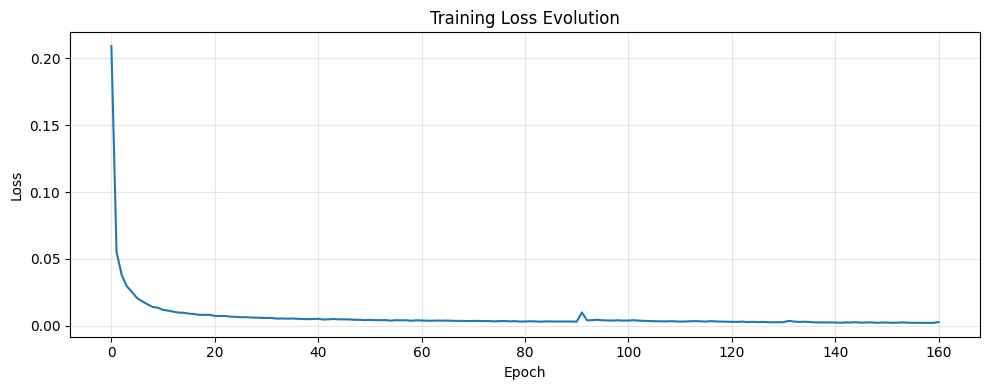

In [19]:
# Plot the losses
losses = meta["losses"]

plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Evolution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sampling

In [20]:
# Sampling
@torch.no_grad()
def sample_conditioned(model, text_encoder, prompt,max_len,word2idx, n_samples=4, device=device):

    # Eval mode
    model.eval()
    text_encoder.eval()
    
    # Tokenized the text
    tokens = torch.tensor([encode(prompt,max_len, word2idx)] * n_samples, dtype=torch.long ).to(device)                                                # (n_samples, MAX_LEN)
    padding_mask = (tokens == word2idx['<PAD>']).to(device)

    # Encode the text
    text_emb = text_encoder(tokens, padding_mask)
    
    # Generate pure noise
    x = torch.randn(n_samples, 3, 64, 64, device=device)

    # Reverse the diffusion loop
    for t in tqdm(reversed(range(T)), desc="Sampling", total=T):

        # Current timestep for all samples
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

        # Predict noise
        eps_pred = model(x, t_tensor, text_emb) # (B, 3, 64, 64)

        # Compute the different value of alpha, alpha_bar and beta
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        # Compute x_{t-1}
        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        x_prev = (1 / torch.sqrt(alpha_t)) * (x - coeff * eps_pred)

        # Add noise only if t > 0 -> To add diversity
        if t > 0:
            z = torch.randn_like(x)
            x_prev = x_prev + torch.sqrt(beta_t) * z

        x = x_prev

    return x # (n_samples, 3, 64, 64)


# Diplay samples
def display_samples(samples, title="Generated Pixel Art"):
    n = samples.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))

    if n == 1:
        axes = [axes]

    for ax, img in zip(axes, samples):
        # Denormalize [-1, 1] → [0, 1]
        img_display = (img.cpu().permute(1, 2, 0).numpy() + 1) / 2
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display, interpolation='nearest')
        ax.axis('off')

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

Sampling: 100%|██████████| 1000/1000 [00:10<00:00, 95.27it/s]


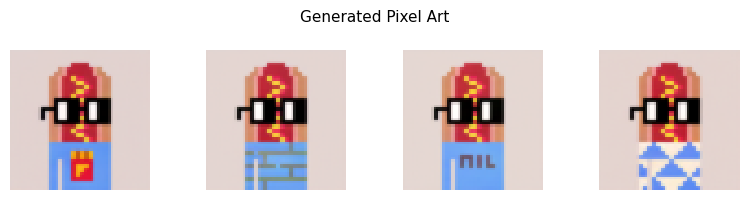

Sampling: 100%|██████████| 1000/1000 [00:09<00:00, 102.54it/s]


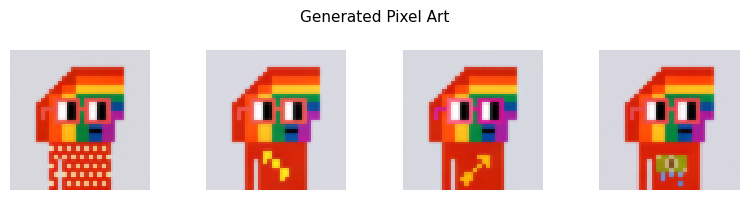

Sampling: 100%|██████████| 1000/1000 [00:09<00:00, 102.70it/s]


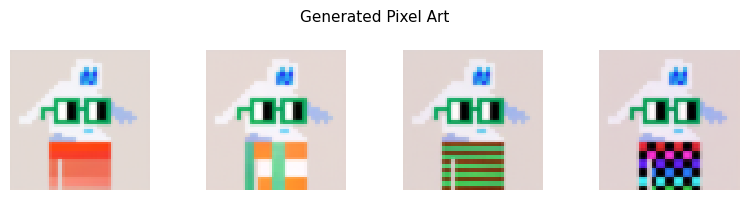

In [22]:
prompts = [
    "a character with square black glasses and a hotdog-shaped head and a blue-colored body on a warm background",
    "a character with round glasses and a rainbow-shaped head and a red-colored body on a cool background",
    "a character with dark green glasses and a yeti-shaped head and a teal-colored body on a warm background",
]

for prompt in prompts:
    samples = sample_conditioned(unet,text_encoder,prompt,max_len,word2idx,4,device)
    display_samples(samples)
